In [25]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

In [26]:
import os

print(os.getcwd())

c:\Bluestock Fintech\mutual-fund-analytics\notebooks


In [27]:
import pandas as pd

nav = pd.read_csv("data/processed/clean_nav_history.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/clean_nav_history.csv'

In [ ]:
import os

print("Current Folder:")
print(os.getcwd())

Current Folder:
c:\Bluestock Fintech\mutual-fund-analytics\notebooks


In [ ]:
print("\nFiles in current folder:")
print(os.listdir())


Files in current folder:
['eda_visual_analysis.ipynb']


In [ ]:
import pandas as pd

nav = pd.read_csv(
    "../data/processed/clean_nav_history.csv"
)

aum = pd.read_csv(
    "../data/raw/03_aum_by_fund_house.csv"
)

sip = pd.read_csv(
    "../data/raw/04_monthly_sip_inflows.csv"
)

category = pd.read_csv(
    "../data/raw/05_category_inflows.csv"
)

investor = pd.read_csv(
    "../data/processed/clean_investor_transactions.csv"
)

folio = pd.read_csv(
    "../data/raw/06_industry_folio_count.csv"
)

portfolio = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

performance = pd.read_csv(
    "../data/processed/clean_scheme_performance.csv"
)

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [ ]:
print(nav.shape)
print(aum.shape)
print(sip.shape)
print(performance.shape)

(46000, 3)
(90, 5)
(48, 6)
(40, 19)


In [33]:
import plotly.express as px

# Convert date
nav["date"] = pd.to_datetime(nav["date"])

# Convert AMFI code to string
nav["amfi_code"] = nav["amfi_code"].astype(str)

# Plot
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend Across Mutual Fund Schemes (2022–2026)"
)

fig.update_layout(
    height=700,
    xaxis_title="Date",
    yaxis_title="NAV",
    legend_title="Scheme"
)

fig.show()
fig.write_html(
    "../reports/charts/nav_trend_analysis.html"
)

print("Saved!")

Saved!


In [ ]:
fig.write_html(
    "../reports/charts/nav_trend_analysis.html"
)

print("NAV chart exported successfully!")

NAV chart exported successfully!


Insight 1:
Daily NAV movement shows overall long-term growth across schemes with visible fluctuations during market correction periods and stronger upward momentum during bullish phases.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check columns first
print(aum.columns)
print(aum.head())

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')
         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168


In [ ]:
print(aum.columns)
print(aum.head())

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')
         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168


In [ ]:
aum["year"] = pd.to_datetime(aum["date"]).dt.year.astype(str)

In [ ]:
print(aum.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     object 
 1   fund_house      90 non-null     object 
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
 5   year            90 non-null     object 
dtypes: float64(1), int64(2), object(3)
memory usage: 4.3+ KB
None


Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes',
       'year'],
      dtype='object')


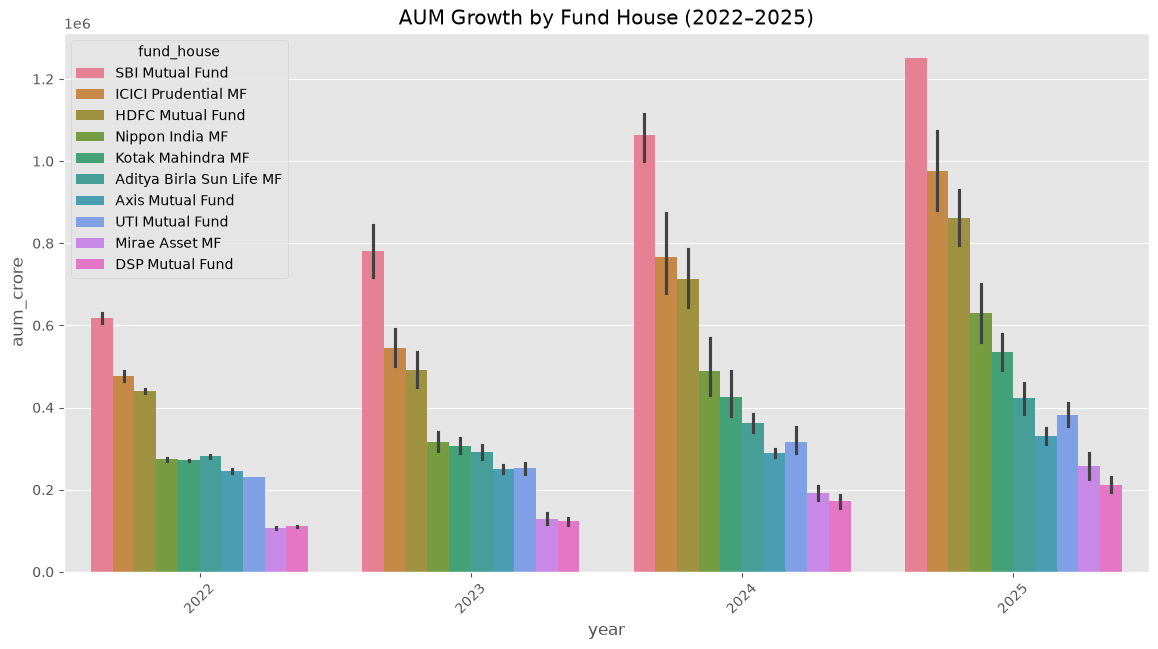

Saved!


<Figure size 640x480 with 0 Axes>

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

print(aum.columns)

# Replace with actual names if different
aum["year"] = aum["year"].astype(str)

plt.figure(figsize=(14,7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xticks(rotation=45)

plt.show()
plt.savefig(
    "../reports/charts/aum_growth_bar_chart.png",
    dpi=300,
    bbox_inches="tight"
)

print("Saved!")

Insight 2:
SBI Mutual Fund maintained the highest AUM growth across years and showed strong market dominance.

In [35]:
import pandas as pd
import plotly.express as px

# Convert month column to date
sip["month"] = pd.to_datetime(sip["month"])

# Sort
sip = sip.sort_values("month")

# Create line chart
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (2022–2025)"
)

# Find peak SIP month
peak = sip.loc[sip["sip_inflow_crore"].idxmax()]

# Annotate peak
fig.add_annotation(
    x=peak["month"],
    y=peak["sip_inflow_crore"],
    text=f'Peak ₹{peak["sip_inflow_crore"]:,.0f} Cr',
    showarrow=True
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)"
)

fig.show()
fig.write_html(
    "../reports/charts/sip_inflow_trend.html"
)

print("Saved!")

Saved!


### Insight 3
Monthly SIP inflows increased consistently across the period and reached the highest recorded value in the final months of the dataset, showing stronger retail participation in mutual funds.

Index(['month', 'category', 'net_inflow_crore'], dtype='object')


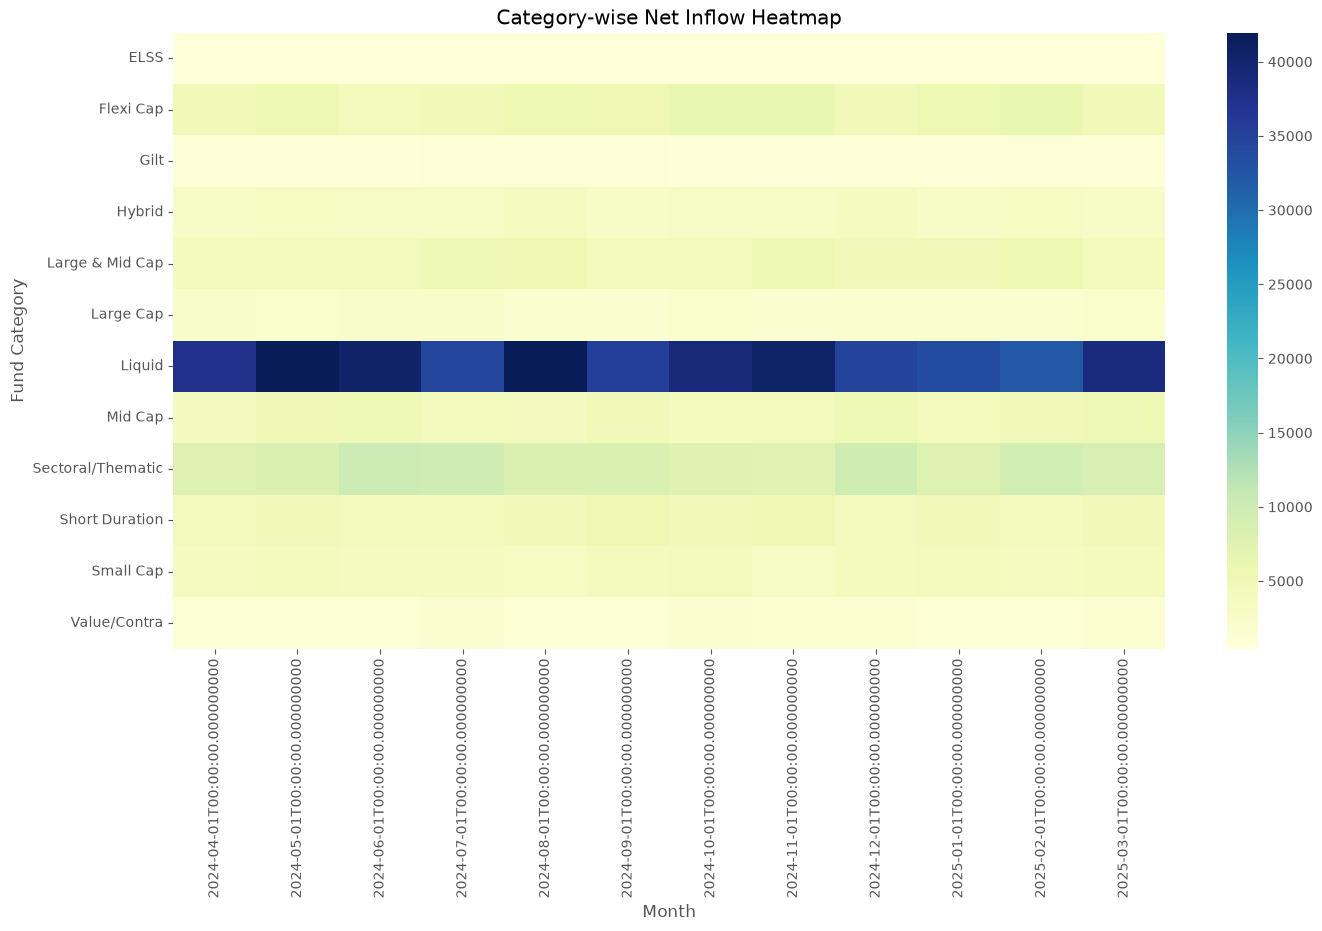

<Figure size 640x480 with 0 Axes>

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Check columns
print(category.columns)

# Convert month column
category["month"] = pd.to_datetime(category["month"])

# Create pivot table
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

# Plot
plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.show()
plt.savefig(
    "../reports/charts/category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

### Insight 4
Fund inflows varied across categories over time, with some categories showing sustained investor interest while others experienced seasonal fluctuations.

In [38]:
import os

print(
    os.listdir("../reports/charts")
)

['aum_growth_bar_chart.png', 'category_inflow_heatmap.png', 'chart_name.png', 'nav_trend_analysis.html', 'sip_inflow_trend.html']


In [40]:
import pandas as pd

tx = pd.read_csv("../data/processed/clean_investor_transactions.csv")

print(tx.columns)
print(tx.shape)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')
(32778, 13)


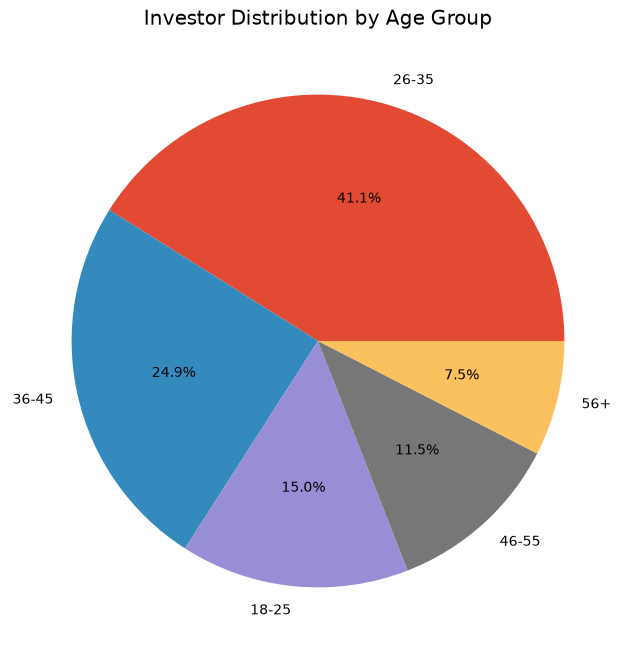

In [41]:
import matplotlib.pyplot as plt

age_counts = tx["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Distribution by Age Group")

plt.savefig(
    "../reports/charts/age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

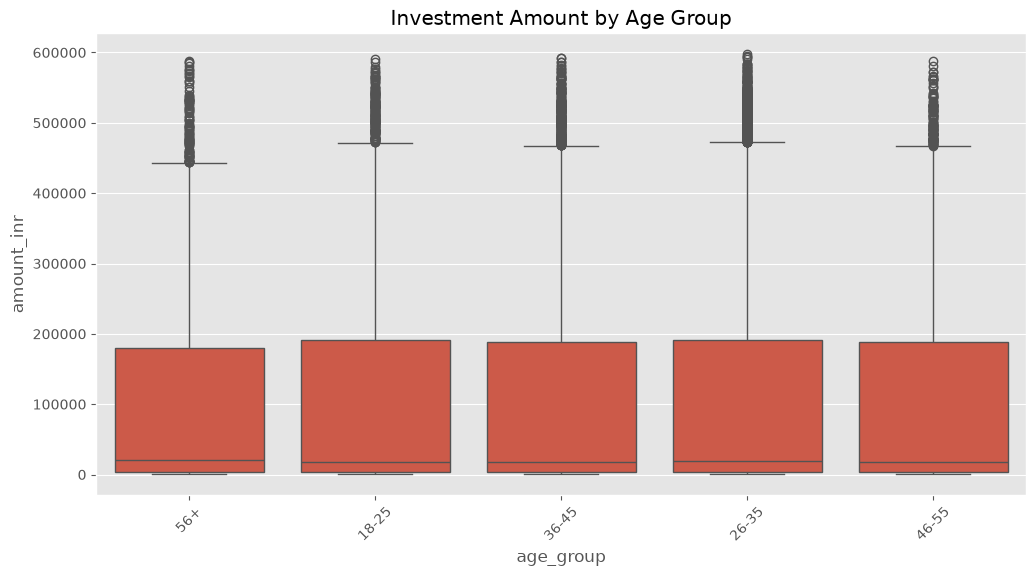

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.boxplot(
    data=tx,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")

plt.xticks(rotation=45)

plt.savefig(
    "../reports/charts/sip_amount_agegroup_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

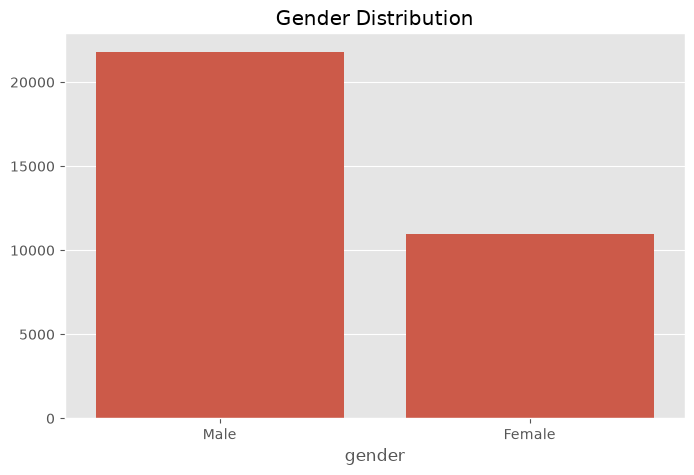

In [43]:
gender = tx["gender"].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(
    x=gender.index,
    y=gender.values
)

plt.title("Gender Distribution")

plt.savefig(
    "../reports/charts/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 5
Investor participation varies across age groups, and transaction behaviour differs between demographics. Gender distribution and investment spread provide additional insight into participation patterns.

In [44]:
import os
print(os.listdir("../reports/charts"))

['age_group_distribution.png', 'aum_growth_bar_chart.png', 'category_inflow_heatmap.png', 'gender_distribution.png', 'nav_trend_analysis.html', 'sip_amount_agegroup_boxplot.png', 'sip_inflow_trend.html']


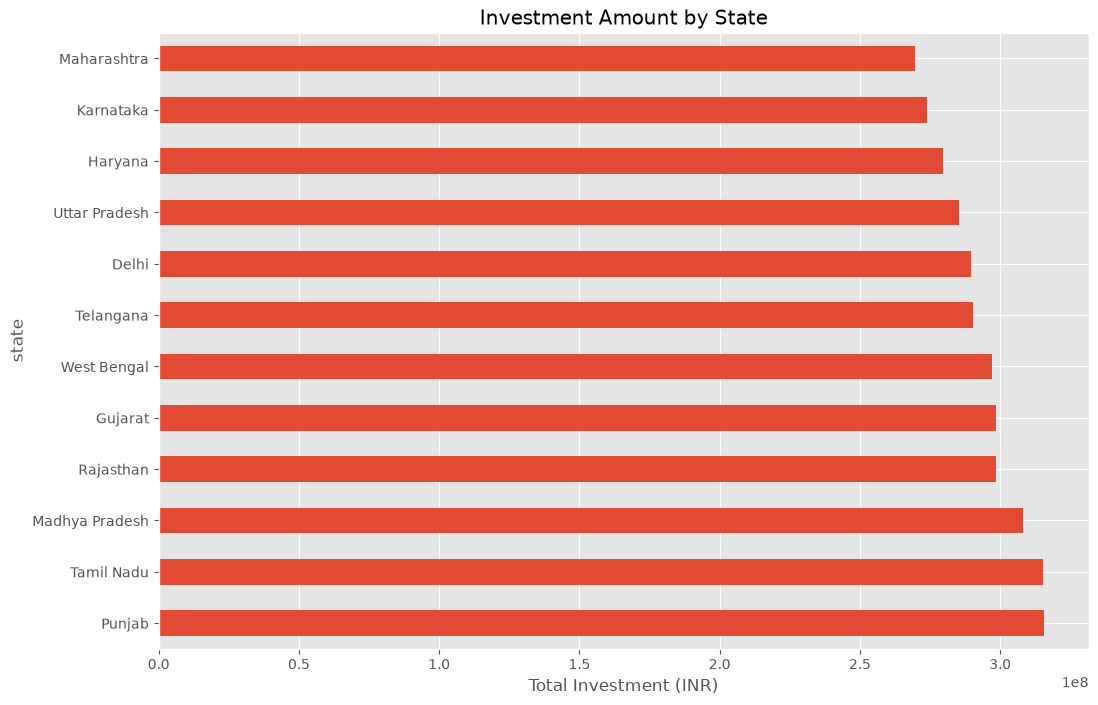

In [46]:
state = (
    tx.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

state.plot(
    kind="barh"
)

plt.title("Investment Amount by State")
plt.xlabel("Total Investment (INR)")

plt.savefig(
    "../reports/charts/state_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

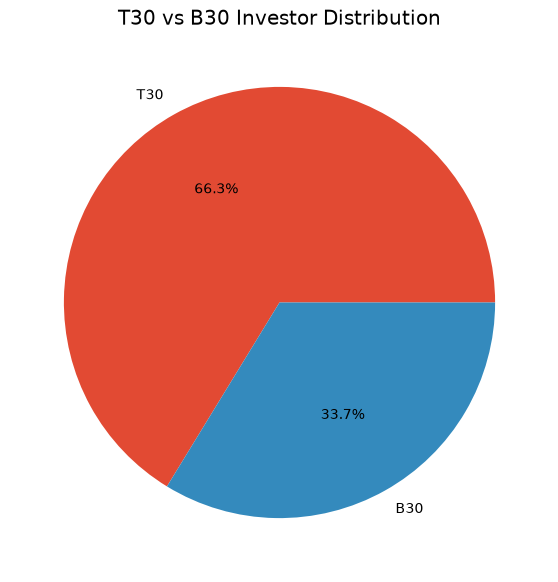

In [47]:
city = tx["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    city,
    labels=city.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.savefig(
    "../reports/charts/city_tier_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [48]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

print(folio.columns)
print(folio.shape)

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')
(21, 6)


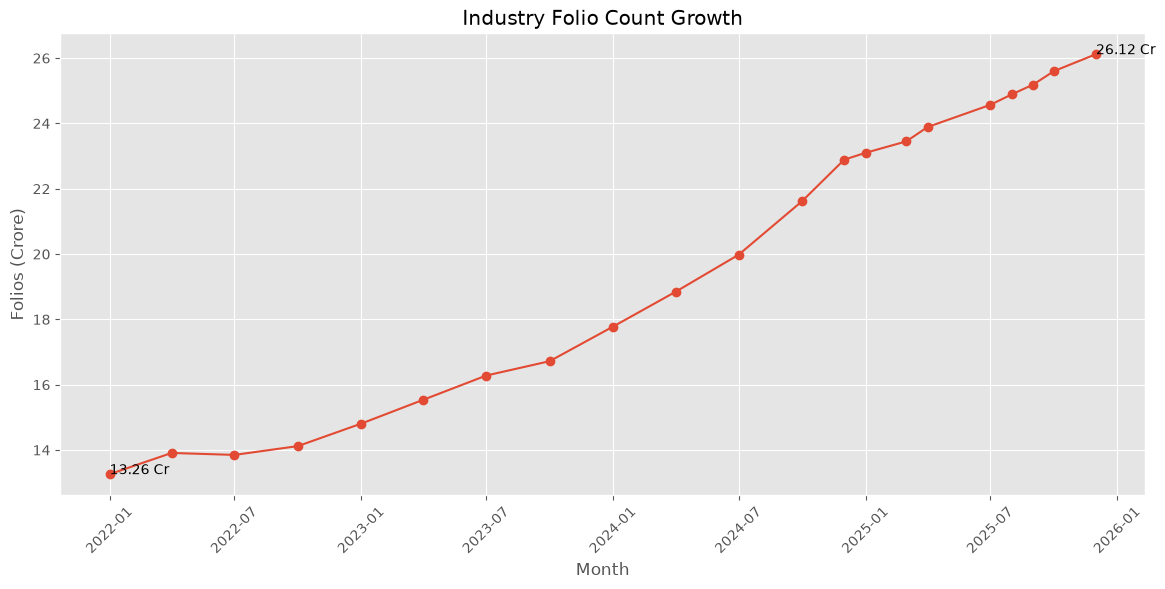

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert month
folio["month"] = pd.to_datetime(folio["month"])

# Sort
folio = folio.sort_values("month")

# Create chart
plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

# Mark first and latest points
plt.annotate(
    f'{folio.iloc[0]["total_folios_crore"]} Cr',
    (
        folio.iloc[0]["month"],
        folio.iloc[0]["total_folios_crore"]
    )
)

plt.annotate(
    f'{folio.iloc[-1]["total_folios_crore"]} Cr',
    (
        folio.iloc[-1]["month"],
        folio.iloc[-1]["total_folios_crore"]
    )
)

plt.title("Industry Folio Count Growth")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.xticks(rotation=45)

plt.savefig(
    "../reports/charts/folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 6
Total folio count showed sustained growth throughout the available period, indicating increasing mutual fund participation and account expansion.

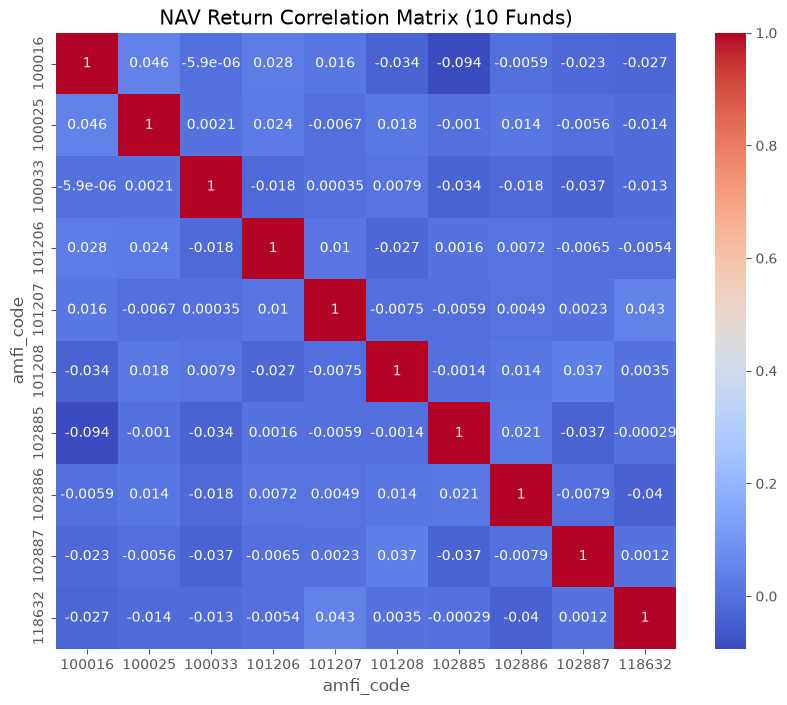

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select 10 funds
selected = nav["amfi_code"].unique()[:10]

nav_10 = nav[
    nav["amfi_code"].isin(selected)
]

# Pivot table
pivot = nav_10.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

# Daily returns
returns = pivot.pct_change()

# Correlation
corr = returns.corr()

# Plot
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "NAV Return Correlation Matrix (10 Funds)"
)

plt.savefig(
    "../reports/charts/nav_return_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 7
Several funds showed positive return correlation, indicating similar movement patterns across market cycles, while others displayed diversification potential.

In [51]:
print(portfolio.columns)
print(portfolio.shape)

portfolio.head()

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')
(322, 8)


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


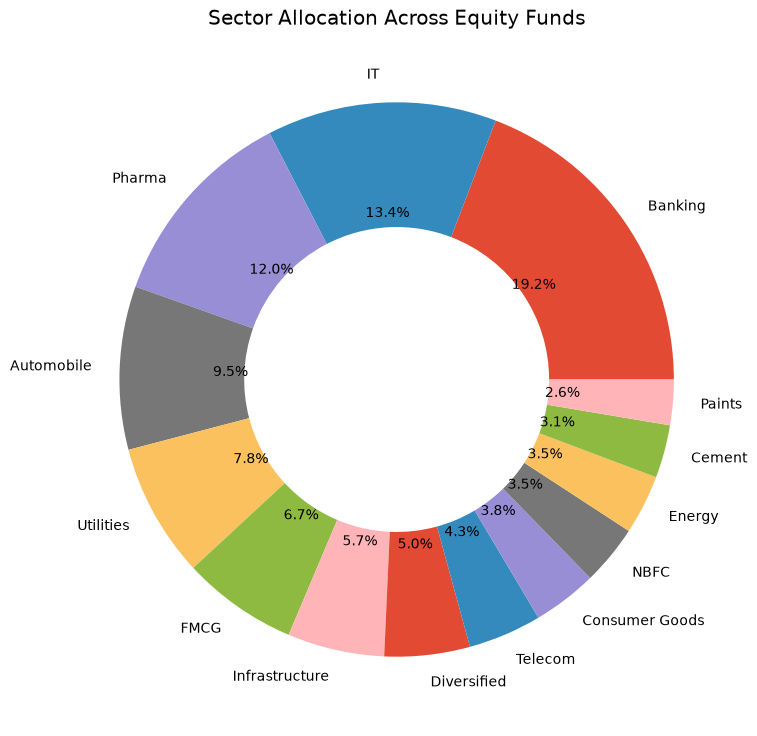

In [52]:
import matplotlib.pyplot as plt

# Aggregate sector allocation
sector = (
    portfolio
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

# Plot donut
plt.figure(figsize=(9,9))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%",
    wedgeprops={"width":0.45}
)

plt.title(
    "Sector Allocation Across Equity Funds"
)

plt.savefig(
    "../reports/charts/sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 8
Portfolio allocation shows concentration in selected sectors while maintaining diversification across industries to balance growth and risk.